In [1]:
import sys
from pathlib import Path
import torch

script_dir = Path.cwd()
sys.path.insert(0, str(script_dir.parent.parent))

from config import PROJECT_ROOT
from model import SSLModel
from data_split import create_train_val_split
from extract_XLSR_feature import extract_features_from_csv
from visualization import plot_training_curves, plot_dataset_comparison
from dataset import create_dataloaders
from train import train
import numpy as np

INFO:numexpr.utils:NumExpr defaulting to 12 threads.
DEBUG:matplotlib:matplotlib data path: /opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/matplotlib/mpl-data
DEBUG:matplotlib:CONFIGDIR=/Users/sleepwalker/.matplotlib
DEBUG:matplotlib:interactive is False
DEBUG:matplotlib:platform is darwin
DEBUG:matplotlib:CACHEDIR=/Users/sleepwalker/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/sleepwalker/.matplotlib/fontlist-v390.json


In [2]:
DATASET_NAME = "Pitt"
DENOISE_METHOD = "mossformer"  # Options: "mossformer" or "FRCRN_SE"

In [3]:
# 使用去噪音频路径
RAW_AUDIO_DIR = PROJECT_ROOT / f"data/denoised/{DATASET_NAME}-{DENOISE_METHOD}"
TRAIN_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-{DENOISE_METHOD}-xlsr-train.csv"
VAL_CSV = PROJECT_ROOT / f"data/processed/{DATASET_NAME}-{DENOISE_METHOD}-xlsr-val.csv"
XLSR_FEATURES_DIR = PROJECT_ROOT / f"data/processed/{DATASET_NAME}_{DENOISE_METHOD}_xlsr_features"
FEATURE_DIR_NAME = f"{DATASET_NAME}_{DENOISE_METHOD}_xlsr_features"
MODEL_OUTPUT_DIR = PROJECT_ROOT / f"models/{DATASET_NAME}-{DENOISE_METHOD}_xlsr_multi_seed"

In [4]:
if torch.cuda.is_available():
      device = torch.device('cuda')
      accelerator = 'gpu'
elif torch.backends.mps.is_available():
      device = torch.device('mps')
      accelerator = 'mps'
else:
      device = torch.device('cpu')
      accelerator = 'cpu'
print(f"Using {device}")

Using mps


## Step 1: Train/Validation Set Split

In [5]:
TRAIN_CSV, VAL_CSV = create_train_val_split(
    raw_audio_dir = RAW_AUDIO_DIR,
    train_csv_path = TRAIN_CSV,
    val_csv_path = VAL_CSV,
    feature_dir_name = FEATURE_DIR_NAME,
    dataset_name = f"{DATASET_NAME}-{DENOISE_METHOD}",
    xlsr=True
)

============= Pitt-mossformer Train(80.0%) and Val(20%) Split Complete! =============
Training set: 440 samples (Control: 193, Dementia: 247)
Validation set: 111 samples (Control: 49, Dementia: 62)


## Step 2: Extract XLSR Features

In [6]:
ssl_model = SSLModel(device, freeze_xlsr=True)

extract_features_from_csv(
    csv_path=TRAIN_CSV,
    split_name="Train Set",
    raw_audio_dir=RAW_AUDIO_DIR,
    xlsr_features_dir=XLSR_FEATURES_DIR,
    device=device,
    ssl_model=ssl_model,
)

extract_features_from_csv(
    csv_path=VAL_CSV,
    split_name="Val Set",
    raw_audio_dir=RAW_AUDIO_DIR,
    xlsr_features_dir=XLSR_FEATURES_DIR,
    device=device,
    ssl_model=ssl_model,
)


XLSR: Loading base model structure


/opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:28: UserWarning: torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.
  warnings.warn("torch.nn.utils.weight_norm is deprecated in favor of torch.nn.utils.parametrizations.weight_norm.")


XLSR: Using original pretrained model

============= Extracting XLSR features for Train Set =============
440 Audio Files


Extracting Train Set:   0%|          | 0/440 [00:00<?, ?it/s]

Successfully extracted: 0
Already exists (skipped): 440
Errors: 0
Total: 440

============= Extracting XLSR features for Val Set =============
111 Audio Files


Extracting Val Set:   0%|          | 0/111 [00:00<?, ?it/s]

DEBUG:numba.core.byteflow:bytecode dump:
>          0	NOP(arg=None, lineno=1137)
           2	LOAD_FAST(arg=0, lineno=1140)
           4	LOAD_CONST(arg=1, lineno=1140)
           6	BINARY_SUBSCR(arg=None, lineno=1140)
           8	STORE_FAST(arg=3, lineno=1140)
          10	LOAD_FAST(arg=1, lineno=1141)
          12	UNARY_NEGATIVE(arg=None, lineno=1141)
          14	LOAD_FAST(arg=3, lineno=1141)
          16	DUP_TOP(arg=None, lineno=1141)
          18	ROT_THREE(arg=None, lineno=1141)
          20	COMPARE_OP(arg=1, lineno=1141)
          22	POP_JUMP_IF_FALSE(arg=32, lineno=1141)
          24	LOAD_FAST(arg=1, lineno=1141)
          26	COMPARE_OP(arg=1, lineno=1141)
          28	POP_JUMP_IF_FALSE(arg=40, lineno=1141)
          30	JUMP_FORWARD(arg=4, lineno=1141)
>         32	POP_TOP(arg=None, lineno=1141)
          34	JUMP_FORWARD(arg=4, lineno=1141)
>         36	LOAD_CONST(arg=1, lineno=1142)
          38	STORE_FAST(arg=3, lineno=1142)
>         40	LOAD_FAST(arg=0, lineno=1144)
         

Successfully extracted: 5
Already exists (skipped): 106
Errors: 0
Total: 111


(5, 106, 111)

## Step 4: Create Data Loaders


In [7]:
train_loader = create_dataloaders(data_csv=TRAIN_CSV, xlsr=True)

val_loader = create_dataloaders(data_csv=VAL_CSV, xlsr=True)

Loading completed: 440 samples
Control: 193, Dementia: 247


Error: Features contain NaN/Inf, skipping: 001-2
Loading completed: 110 samples
Control: 49, Dementia: 61




## Step 5: Define Training Function and Model


In [8]:
all_results = {
    'seeds': [], 
    'val_accs': [], 
    'val_losses': [], 
    'control_accs': [], 
    'dementia_accs': [], 
    'f1_scores': []
}

### 1st Random Seed = 21


Seed 21:
Val Acc=58.18%, F1=0.6230, Val Loss=0.6949
Control Acc=53.06%, Dementia Acc=62.30%
Early stop at: epoch 13 (best epoch: 3)


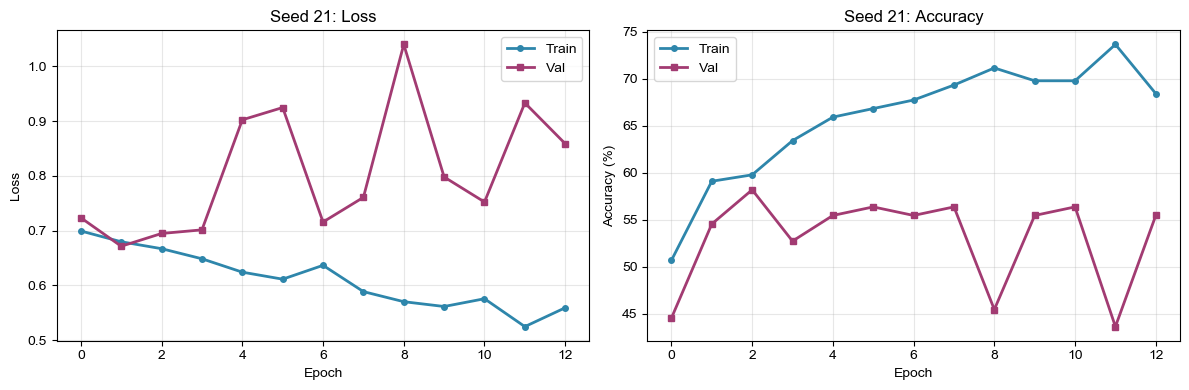

In [9]:
seed, metrics, history = train(seed=21, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 2nd Random Seed = 42

Seed 42:
Val Acc=60.91%, F1=0.6950, Val Loss=0.9800
Control Acc=36.73%, Dementia Acc=80.33%
Early stop at: epoch 38 (best epoch: 28)


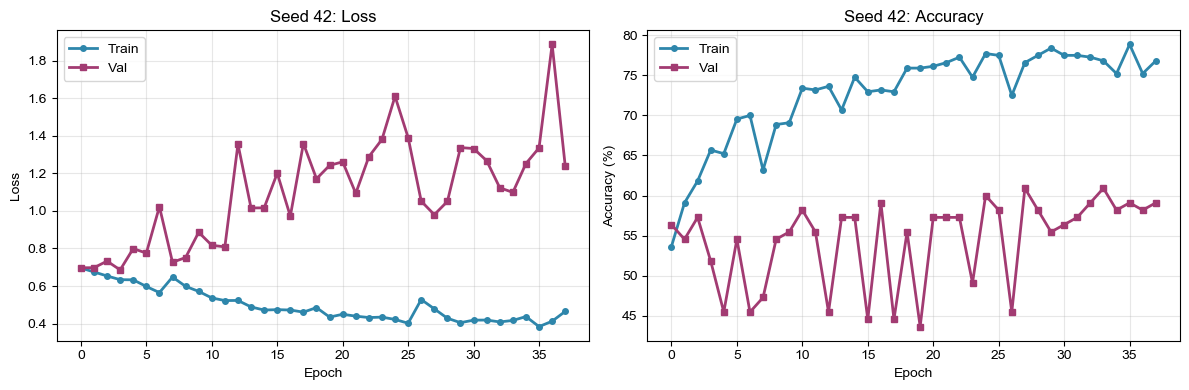

In [10]:
seed, metrics, history = train(seed=42, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 3rd Random Seed = 84

Seed 84:
Val Acc=58.18%, F1=0.7013, Val Loss=0.7767
Control Acc=20.41%, Dementia Acc=88.52%
Early stop at: epoch 17 (best epoch: 7)


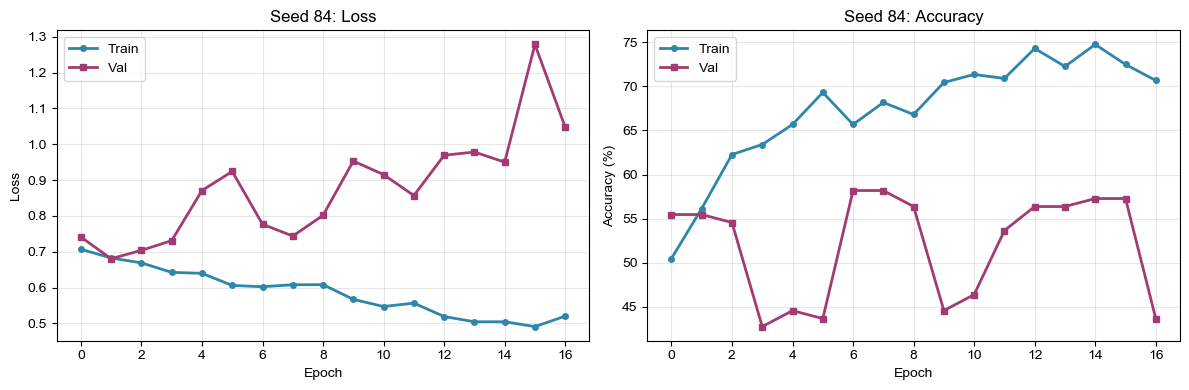

In [11]:
seed, metrics, history = train(seed=84, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 4th Random Seed = 168

Seed 168:
Val Acc=59.09%, F1=0.6715, Val Loss=0.8984
Control Acc=38.78%, Dementia Acc=75.41%
Early stop at: epoch 20 (best epoch: 10)


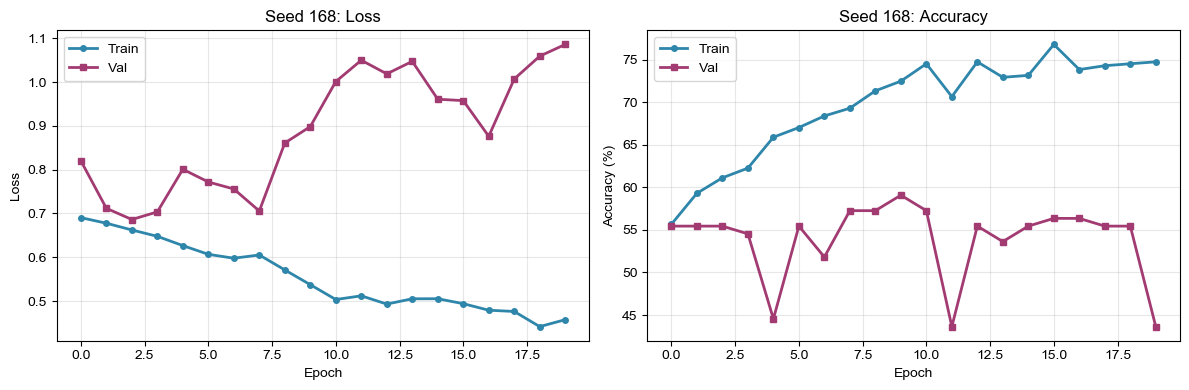

In [12]:
seed, metrics, history = train(seed=168, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

### 5th Random Seed = 336

Seed 336:
Val Acc=56.36%, F1=0.5862, Val Loss=0.6939
Control Acc=57.14%, Dementia Acc=55.74%
Early stop at: epoch 11 (best epoch: 1)


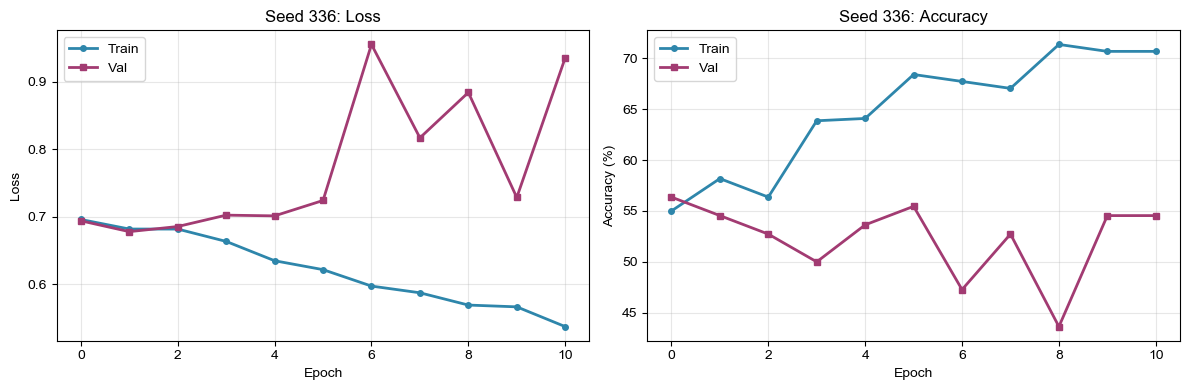

In [13]:
seed, metrics, history = train(seed=336, 
                               train_loader=train_loader, 
                               val_loader=val_loader, 
                               output_dir=MODEL_OUTPUT_DIR, 
                               device=device, 
                               xlsr=True)

all_results['seeds'].append(seed)
all_results['val_accs'].append(metrics['val_acc'])
all_results['val_losses'].append(metrics['val_loss'])
all_results['control_accs'].append(metrics['control_acc'])
all_results['dementia_accs'].append(metrics['dementia_acc'])
all_results['f1_scores'].append(metrics['f1_score'])

# Plot training curves
plot_training_curves(
    epochs=history['epochs'],
    train_loss=history['train_losses'],
    val_loss=history['val_losses'],
    train_acc=history['train_accs'],
    val_acc=history['val_accs'],
    title_prefix=f'Seed {seed}'
)

## Step 6: Summary of Results

In [14]:
seeds = all_results['seeds']
val_accs = [acc*100 for acc in all_results['val_accs']]
val_losses = all_results['val_losses']
control_accs = [acc*100 for acc in all_results['control_accs']]
dementia_accs = [acc*100 for acc in all_results['dementia_accs']]
f1_scores = all_results['f1_scores']

# Calculate statistics (mean and std)
mean_acc = np.mean(val_accs)
std_acc = np.std(val_accs, ddof=1)

mean_loss = np.mean(val_losses)
std_loss = np.std(val_losses, ddof=1)

mean_control_acc = np.mean(control_accs)
std_control_acc = np.std(control_accs, ddof=1)

mean_dementia_acc = np.mean(dementia_accs)
std_dementia_acc = np.std(dementia_accs, ddof=1)

mean_f1 = np.mean(f1_scores)
std_f1 = np.std(f1_scores, ddof=1)

print(f"\nMean Validation Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")
print(f"Mean Validation Loss: {mean_loss:.4f} ± {std_loss:.4f}")
print(f"Mean Control Accuracy: {mean_control_acc:.2f}% ± {std_control_acc:.2f}%")
print(f"Mean Dementia Accuracy: {mean_dementia_acc:.2f}% ± {std_dementia_acc:.2f}%")
print(f"Mean F1 Score: {mean_f1:.4f} ± {std_f1:.4f}")

print(f"\nDetailed Results:")
for i, seed in enumerate(seeds):
    print(f"Seed {seed}: Acc={val_accs[i]:.2f}%, Loss={val_losses[i]:.4f}, "
          f"Control Acc={control_accs[i]:.2f}%, Dementia Acc={dementia_accs[i]:.2f}%, F1={f1_scores[i]:.4f}")


Mean Validation Accuracy: 58.55% ± 1.65%
Mean Validation Loss: 0.8088 ± 0.1270
Mean Control Accuracy: 41.22% ± 14.60%
Mean Dementia Accuracy: 72.46% ± 13.34%
Mean F1 Score: 0.6554 ± 0.0494

Detailed Results:
Seed 21: Acc=58.18%, Loss=0.6949, Control Acc=53.06%, Dementia Acc=62.30%, F1=0.6230
Seed 42: Acc=60.91%, Loss=0.9800, Control Acc=36.73%, Dementia Acc=80.33%, F1=0.6950
Seed 84: Acc=58.18%, Loss=0.7767, Control Acc=20.41%, Dementia Acc=88.52%, F1=0.7013
Seed 168: Acc=59.09%, Loss=0.8984, Control Acc=38.78%, Dementia Acc=75.41%, F1=0.6715
Seed 336: Acc=56.36%, Loss=0.6939, Control Acc=57.14%, Dementia Acc=55.74%, F1=0.5862


## Step 7: Test Best Model on Lu Dataset


In [15]:
# Find the best model: highest accuracy, then lowest loss if tied
max_acc = max(all_results['val_accs'])
# Find all indices with max accuracy
max_acc_indices = [i for i, acc in enumerate(all_results['val_accs']) if acc == max_acc]

# If multiple models have the same max accuracy, choose the one with lowest loss
if len(max_acc_indices) > 1:
    best_idx = min(max_acc_indices, key=lambda i: all_results['val_losses'][i])
    print(f"Multiple models with accuracy {max_acc*100:.2f}%, selecting one with lowest loss")
else:
    best_idx = max_acc_indices[0]

BEST_SEED = all_results['seeds'][best_idx]
BEST_VAL_ACC = all_results['val_accs'][best_idx] * 100
BEST_VAL_LOSS = all_results['val_losses'][best_idx]
BEST_F1 = all_results['f1_scores'][best_idx]

print(f"\nBest Model: Seed {BEST_SEED}")
print(f"Validation Accuracy: {BEST_VAL_ACC:.2f}%")
print(f"Validation Loss: {BEST_VAL_LOSS:.4f}")
print(f"F1 Score: {BEST_F1:.4f}")

BEST_MODEL_PATH = MODEL_OUTPUT_DIR / f"seed_{BEST_SEED}" / "best.pth"
print(f"Model Path: {BEST_MODEL_PATH}")



Best Model: Seed 42
Validation Accuracy: 60.91%
Validation Loss: 0.9800
F1 Score: 0.6950
Model Path: /Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/few-shot_is_all_you_need/ad_detection/models/Pitt-mossformer_xlsr_multi_seed/seed_42/best.pth


In [16]:
TEST_DATASET = "Lu"
LU_AUDIO_DIR = PROJECT_ROOT / f"data/raw/{TEST_DATASET}"
LU_FEATURES_DIR = PROJECT_ROOT / f"data/processed/{TEST_DATASET}_xlsr_features"
LU_CSV_PATH = PROJECT_ROOT / f"data/processed/{TEST_DATASET}-xlsr-test.csv"
LU_FEATURE_DIR_NAME = f"{TEST_DATASET}_xlsr_features"

# Create features directory
LU_FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# Collect audio files from Lu dataset
import pandas as pd
test_samples = []

for label_dir in ["Control", "Dementia"]:
    label_audio_dir = LU_AUDIO_DIR / label_dir
    if not label_audio_dir.exists():
        print(f"Error: Directory does not exist: {label_audio_dir}")
        continue
    
    label = 0 if label_dir == "Control" else 1
    
    audio_files = list(label_audio_dir.glob("*.wav")) + list(label_audio_dir.glob("*.mp3"))
    for audio_file in sorted(audio_files):
        session_id = audio_file.stem
        feature_path = f"{LU_FEATURE_DIR_NAME}/{session_id}.xlsr.pt"
        
        test_samples.append({
            "session_id": session_id,
            "xlsr_path": feature_path,
            "ad": label,
            "audio_path": str(audio_file.relative_to(PROJECT_ROOT))
        })

# Create CSV
test_df = pd.DataFrame(test_samples)
LU_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
test_df.to_csv(LU_CSV_PATH, index=False)

In [ ]:
extract_features_from_csv(
    csv_path=LU_CSV_PATH,
    split_name=f"{TEST_DATASET} Set",
    raw_audio_dir=LU_AUDIO_DIR,
    xlsr_features_dir=LU_FEATURES_DIR,
    device=device,
    ssl_model=ssl_model,
)


============= Extracting XLSR features for Lu Set =============
53 Audio Files


Extracting Lu Set:   0%|          | 0/53 [00:00<?, ?it/s]

DEBUG:numba.core.byteflow:bytecode dump:
>          0	NOP(arg=None, lineno=81)
           2	LOAD_GLOBAL(arg=0, lineno=86)
           4	LOAD_FAST(arg=0, lineno=86)
           6	LOAD_FAST(arg=1, lineno=86)
           8	LOAD_FAST(arg=2, lineno=86)
          10	LOAD_FAST(arg=3, lineno=86)
          12	LOAD_FAST(arg=4, lineno=86)
          14	LOAD_FAST(arg=5, lineno=86)
          16	LOAD_FAST(arg=6, lineno=86)
          18	CALL_FUNCTION(arg=7, lineno=86)
          20	POP_TOP(arg=None, lineno=86)
          22	LOAD_CONST(arg=0, lineno=86)
          24	RETURN_VALUE(arg=None, lineno=86)
DEBUG:numba.core.byteflow:pending: deque([State(pc_initial=0 nstack_initial=0)])
DEBUG:numba.core.byteflow:stack: []
DEBUG:numba.core.byteflow:state.pc_initial: State(pc_initial=0 nstack_initial=0)
DEBUG:numba.core.byteflow:dispatch pc=0, inst=NOP(arg=None, lineno=81)
DEBUG:numba.core.byteflow:stack []
DEBUG:numba.core.byteflow:dispatch pc=2, inst=LOAD_GLOBAL(arg=0, lineno=86)
DEBUG:numba.core.byteflow:stack []


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3526, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/z2/s0s8yh9904sfcpkv_c0l9qq00000gn/T/ipykernel_23962/1805670546.py", line 1, in <module>
    extract_features_from_csv(
  File "/Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/few-shot_is_all_you_need/ad_detection/train/extract_XLSR_feature.py", line 103, in extract_features_from_csv
    emb, layerresult = ssl_model.extract_feat(audio_tensor)
  File "/Users/sleepwalker/Library/Mobile Documents/com~apple~CloudDocs/Code-In-iCloud/few-shot_is_all_you_need/ad_detection/train/model.py", line 78, in extract_feat
    model_output = self.model(input_tmp, mask=False, features_only=True)
  File "/opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/torch/nn/modules/module.py", line 1532, in _wrapped_call_impl
    return self._ca

Traceback (most recent call last):
  File "/opt/anaconda3/envs/pytorch_env/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/envs/pytorch_env/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/opt/anaconda3/envs/pytorch_env/lib/python3.9/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/opt/anaconda3/envs/pytorch_env/lib/python3.9/asyncio/base_events.py", line 601, in run_forever
    self._run_once()

: 

In [ ]:
# Load the best model
from model import AD_XLSR_Model

print(f"Loading best model from: {BEST_MODEL_PATH}")

# Create model with XLSR configuration
from config import XLSR_DROPOUT

test_model = AD_XLSR_Model(dropout=XLSR_DROPOUT)

# Load checkpoint
checkpoint = torch.load(BEST_MODEL_PATH, map_location='cpu', weights_only=False)

if isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
    state_dict = checkpoint['state_dict']
else:
    state_dict = checkpoint

# Handle potential 'model.' prefix in state dict keys
new_state_dict = {}
for key, value in state_dict.items():
    if key.startswith('model.'):
        new_key = key[6:]
        new_state_dict[new_key] = value
    else:
        new_state_dict[key] = value

test_model.load_state_dict(new_state_dict)
test_model = test_model.to(device)
test_model.eval()

print(f"Model loaded successfully")

In [ ]:
# Test on Lu dataset
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
from tqdm.auto import tqdm

# Create test data loader
lu_test_loader = create_dataloaders(
    data_csv=LU_CSV_PATH,
    batch_size=32,
    num_workers=0,
    xlsr=True
)

# Perform predictions
all_preds = []
all_labels = []
all_probs = []

test_model.eval()
with torch.no_grad():
    for features, labels, masks in tqdm(lu_test_loader, desc=f"Testing on {TEST_DATASET}"):
        features = features.to(device)
        labels = labels.to(device)
        masks = masks.to(device)
        
        logits = test_model(features, masks)
        probs = F.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate metrics
lu_accuracy = accuracy_score(all_labels, all_preds)

# Calculate accuracy for each class
control_mask = all_labels == 0
dementia_mask = all_labels == 1

control_acc = accuracy_score(all_labels[control_mask], all_preds[control_mask])
dementia_acc = accuracy_score(all_labels[dementia_mask], all_preds[dementia_mask])

In [ ]:
# Performance Comparison Visualization
import matplotlib.pyplot as plt

# Set font properties
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Prepare data for visualization
dataset_names = [DATASET_NAME, TEST_DATASET]
accuracies = [BEST_VAL_ACC, lu_accuracy * 100]

# Colors for the bars
color_map = {'Pitt': '#27F5EE', 'ADReSS': '#B727F5', 'Lu': '#F5A623'}
colors = [color_map.get(name, '#888888') for name in dataset_names]

# Create bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(dataset_names, accuracies, color=colors, alpha=0.7, width=0.5)

# Set labels and title
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title(f'{DATASET_NAME}-Trained Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on top of bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{acc:.2f}%',
            ha='center', va='bottom',
            fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

# Calculate F1 score for Lu dataset
from sklearn.metrics import f1_score
lu_f1 = f1_score(all_labels, all_preds, pos_label=1)

# Get best model metrics
BEST_CONTROL_ACC = all_results['control_accs'][best_idx] * 100
BEST_DEMENTIA_ACC = all_results['dementia_accs'][best_idx] * 100

# Print summary
print(f"{DATASET_NAME} Dataset (Validation):")
print(f"Overall Accuracy: {BEST_VAL_ACC:.2f}%, F1 Score: {BEST_F1:.4f}")
print(f"Control Accuracy: {BEST_CONTROL_ACC:.2f}%, Dementia Accuracy: {BEST_DEMENTIA_ACC:.2f}%")

print(f"\n{TEST_DATASET} Dataset (Test):")
print(f"Overall Accuracy: {lu_accuracy*100:.2f}%, F1 Score: {lu_f1:.4f}")
print(f"Control Accuracy: {control_acc*100:.2f}%, Dementia Accuracy: {dementia_acc*100:.2f}%")

print(f"\nPerformance Drop: {BEST_VAL_ACC - lu_accuracy*100:.2f}%")


In [ ]:
torch.cuda.empty_cache()